# Fase 2 — Comprensión de los Datos
## Sección 02: Calidad de Datos — Diagnóstico Inicial

**Notebook:** `notebooks/02_EDA_calidad_datos.ipynb`
**Responsable:** Sofía | **Apoyo:** Steve
**Objetivo:** Evaluar la calidad de los 16 datasets (Grupo A y B): completitud, duplicados, nulos y patrones de datos faltantes.

## Configuración inicial

In [1]:
from config import *

---
## Estadísticas de calidad por dataset

### Cargar todos los datasets y calcular métricas de calidad

In [2]:
A_FILES = [
    ("A1", "A1_colombia_housing_properties.csv"),
    ("A2", "A2_fincaraiz_colombia.csv"),
    ("A3", "A3_colombia_house_prediction.csv"),
    ("A4", "A4_real_estate_bogota.csv"),
    ("A5", "A5_medellin_properties_2023.csv"),
    ("A6", "A6_real_estate_bogota_2023.csv"),
    ("A7", "A7_fincaraiz_villavicencio_scraping.csv"),
    ("A8", "A8_carac_pre_viv_nueva.csv"),
]

B_FILES = [
    ("B1", "B1_indices_precios_vivienda.csv"),
    ("B2", "B2_tasa_hipotecaria_semanal.csv"),
    ("B3", "B3_salario_minimo_historico.csv"),
    ("B4", "B4_ipc_colombia_anual.csv"),
    ("B5", "B5_geih_empleo_colombia.csv"),
    ("B6", "B6_qcon_confianza_constructora.csv"),
    ("B7", "B7_qcon_licencias_construccion.csv"),
    ("B8", "B8_geo_estados_localidades.csv"),
]

ALL_FILES = A_FILES + B_FILES

datasets = {}
for fid, fname in ALL_FILES:
    fpath = os.path.join(RAW, fname)
    try:
        df = pd.read_csv(fpath, encoding="utf-8-sig", low_memory=False)
        datasets[fid] = df
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"[OK] {fid:2s} {fname:45s} {df.shape[0]:>8,} filas x {df.shape[1]:>3} cols  {size_mb:>8.1f} MB")
    except Exception as e:
        print(f"[ERR] {fid:2s} {fname}: {e}")
        datasets[fid] = None


[OK] A1 A1_colombia_housing_properties.csv             997,623 filas x  17 cols     581.8 MB
[OK] A2 A2_fincaraiz_colombia.csv                      142,833 filas x  28 cols      52.5 MB
[OK] A3 A3_colombia_house_prediction.csv               145,552 filas x  37 cols      26.8 MB
[OK] A4 A4_real_estate_bogota.csv                        9,520 filas x   8 cols       0.9 MB
[OK] A5 A5_medellin_properties_2023.csv                  9,999 filas x  12 cols       0.9 MB
[OK] A6 A6_real_estate_bogota_2023.csv                     585 filas x  21 cols       0.5 MB
[OK] A7 A7_fincaraiz_villavicencio_scraping.csv          1,048 filas x  24 cols       0.3 MB
[OK] A8 A8_carac_pre_viv_nueva.csv                          32 filas x  14 cols       0.0 MB
[OK] B1 B1_indices_precios_vivienda.csv                    332 filas x  16 cols       0.0 MB
[OK] B2 B2_tasa_hipotecaria_semanal.csv                  1,255 filas x   7 cols       0.1 MB
[OK] B3 B3_salario_minimo_historico.csv                     43 filas x

### Tabla resumen de calidad — Grupo A

In [3]:
rows = []
for fid, _ in A_FILES:
    df = datasets[fid]
    if df is None:
        continue
    n_rows, n_cols = df.shape
    size_mb = df.memory_usage(deep=True).sum() / 1e6
    pct_nulos_total = df.isnull().sum().sum() / (n_rows * n_cols) * 100
    duplicados = df.duplicated().sum()
    pct_precio_nulo = None
    pct_area_nula = None

    for precio_col in ["price", "precio", "valor", "precios", "Valor", "precio_cop", "Precio"]:
        if precio_col in df.columns:
            pct_precio_nulo = round(df[precio_col].isnull().mean() * 100, 2)
            break

    for area_col in ["area", "Area", "Area Construida", "area_m2"]:
        if area_col in df.columns:
            pct_area_nula = round(df[area_col].isnull().mean() * 100, 2)
            break

    rows.append({
        "Dataset": fid,
        "Filas": n_rows,
        "Columnas": n_cols,
        "Memoria (MB)": round(size_mb, 2),
        "% Nulos total": round(pct_nulos_total, 2),
        "Duplicados": duplicados,
        "% Precio nulo": pct_precio_nulo if pct_precio_nulo is not None else "N/A",
        "% Area nula": pct_area_nula if pct_area_nula is not None else "N/A",
    })

df_quality_a = pd.DataFrame(rows)
display(df_quality_a)


,Dataset,Filas,Columnas,Memoria (MB),% Nulos total,Duplicados,% Precio nulo,% Area nula
0,A1,997623,17,1181.22,12.18,0,0.0,N/A
1,A2,142833,28,186.08,14.41,0,0.0,0.0
2,A3,145552,37,112.18,38.13,70794,0.0,0.02
3,A4,9520,8,2.97,0.06,3575,0.0,N/A
4,A5,9999,12,3.43,5.02,100,0.0,0.0
5,A6,585,21,0.80,0.28,0,0.0,N/A
6,A7,1048,24,0.94,2.64,0,0.0,0.0
7,A8,32,14,0.01,0.00,0,0.0,0.0


### Tabla resumen de calidad — Grupo B

In [4]:
rows_b = []
for fid, _ in B_FILES:
    df = datasets[fid]
    if df is None:
        continue
    n_rows, n_cols = df.shape
    size_mb = df.memory_usage(deep=True).sum() / 1e6
    pct_nulos_total = df.isnull().sum().sum() / (n_rows * n_cols) * 100
    duplicados = df.duplicated().sum()

    rows_b.append({
        "Dataset": fid,
        "Filas": n_rows,
        "Columnas": n_cols,
        "Memoria (MB)": round(size_mb, 2),
        "% Nulos total": round(pct_nulos_total, 2),
        "Duplicados": duplicados,
    })

df_quality_b = pd.DataFrame(rows_b)
display(df_quality_b)


,Dataset,Filas,Columnas,Memoria (MB),% Nulos total,Duplicados
0,B1,332,16,0.09,23.40,0
1,B2,1255,7,0.13,0.00,0
2,B3,43,5,0.00,7.44,0
3,B4,10,2,0.00,0.00,0
4,B5,1202,6,0.18,8.37,0
5,B6,148,2,0.01,0.00,0
6,B7,152,2,0.01,0.00,0
7,B8,293,2,0.04,0.00,0


### Resumen consolidado de calidad

In [13]:
print("===== RESUMEN CALIDAD GRUPO A =====")
display(df_quality_a)

print("\n===== RESUMEN CALIDAD GRUPO B =====")
display(df_quality_b)

path_a = os.path.join(PROC, "calidad_grupo_a.csv")
path_b = os.path.join(PROC, "calidad_grupo_b.csv")

df_quality_a.to_csv(path_a, index=False)
df_quality_b.to_csv(path_b, index=False)

print("\nArchivos guardados:")
print(f"Grupo A: {path_a}")
print(f"Grupo B: {path_b}")

===== RESUMEN CALIDAD GRUPO A =====


,Dataset,Filas,Columnas,Memoria (MB),% Nulos total,Duplicados,% Precio nulo,% Area nula
0,A1,997623,17,1181.22,12.18,0,0.0,N/A
1,A2,142833,28,186.08,14.41,0,0.0,0.0
2,A3,145552,37,112.18,38.13,70794,0.0,0.02
3,A4,9520,8,2.97,0.06,3575,0.0,N/A
4,A5,9999,12,3.43,5.02,100,0.0,0.0
5,A6,585,21,0.80,0.28,0,0.0,N/A
6,A7,1048,24,0.94,2.64,0,0.0,0.0
7,A8,32,14,0.01,0.00,0,0.0,0.0



===== RESUMEN CALIDAD GRUPO B =====


,Dataset,Filas,Columnas,Memoria (MB),% Nulos total,Duplicados
0,B1,332,16,0.09,23.40,0
1,B2,1255,7,0.13,0.00,0
2,B3,43,5,0.00,7.44,0
3,B4,10,2,0.00,0.00,0
4,B5,1202,6,0.18,8.37,0
5,B6,148,2,0.01,0.00,0
6,B7,152,2,0.01,0.00,0
7,B8,293,2,0.04,0.00,0



Archivos guardados:
Grupo A: ..\data\processed\calidad_grupo_a.csv
Grupo B: ..\data\processed\calidad_grupo_b.csv


---
## Análisis de nulos

### Mapa de calor de valores nulos (muestra 5000 filas por dataset)

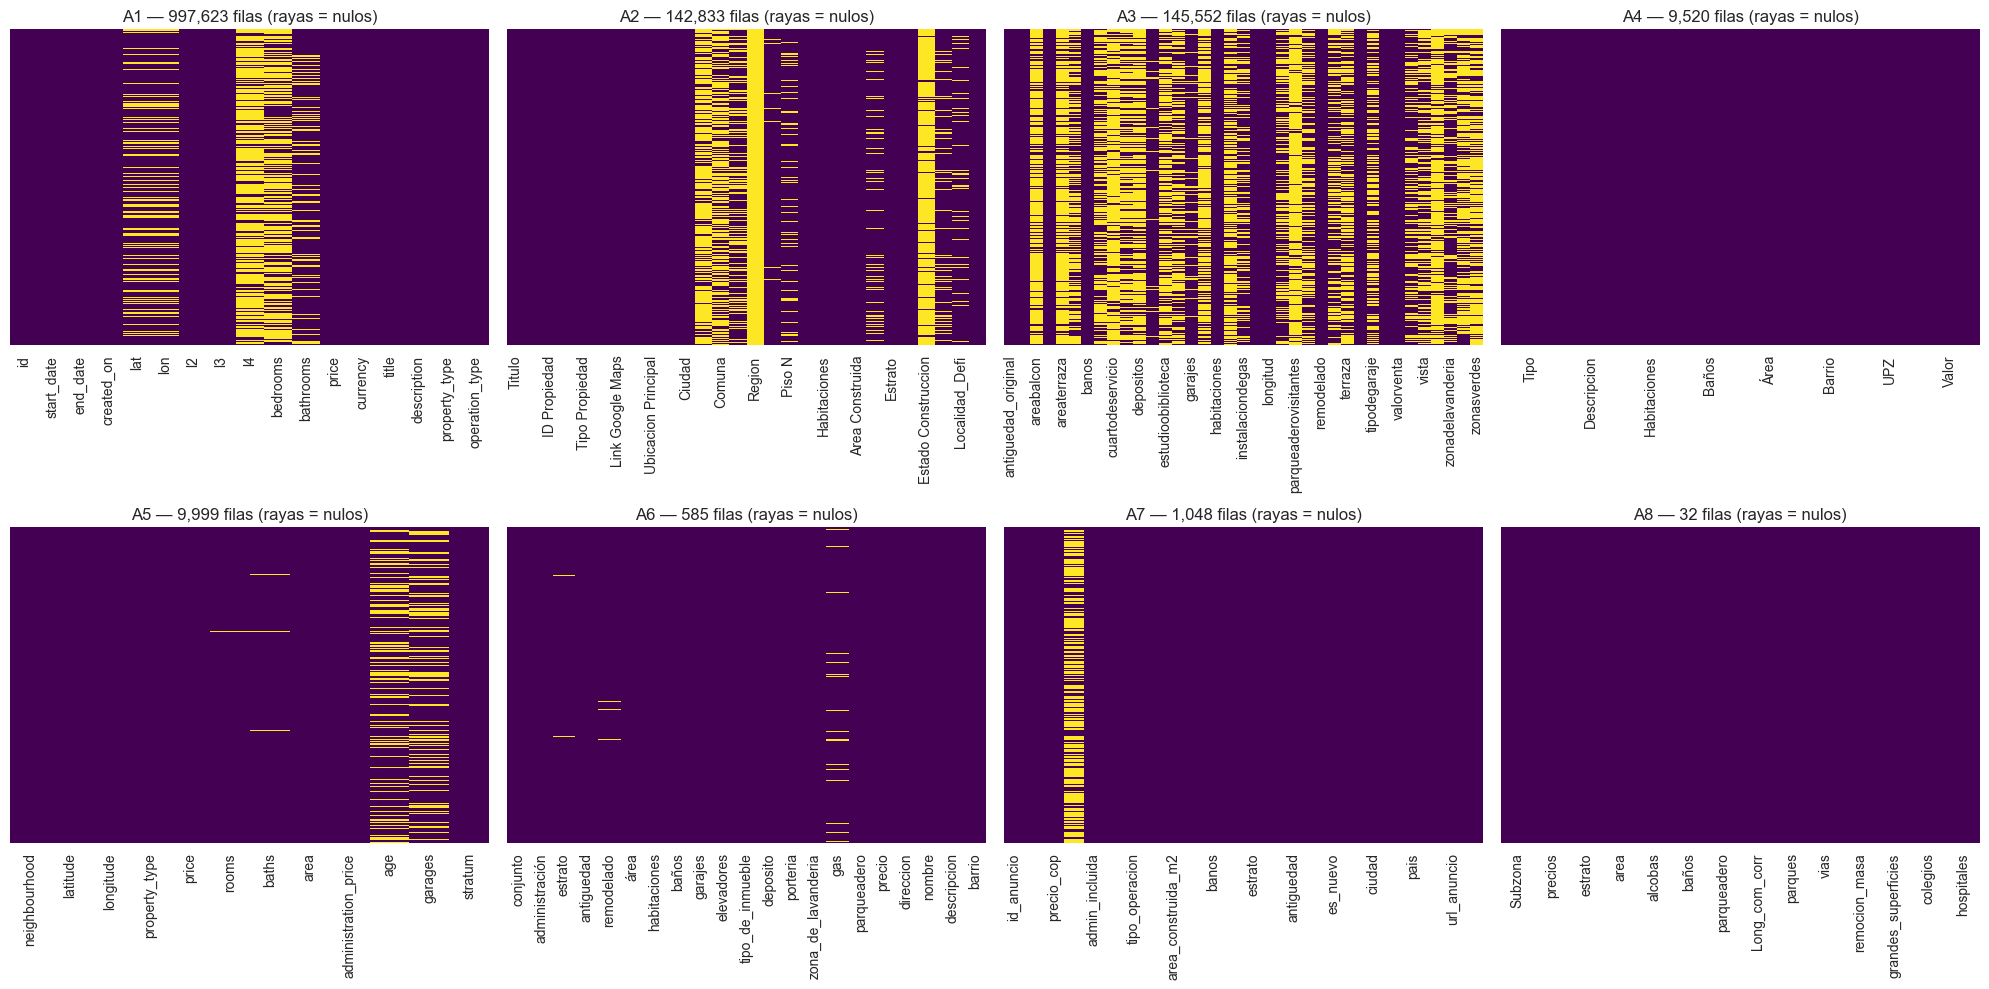

Mapa de calor guardado en: ..\docs\figures\mapa_calor_nulos_grupo_a.png


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (fid, _) in enumerate(A_FILES):
    df = datasets[fid]
    if df is None:
        axes[i].text(0.5, 0.5, f"{fid}: error carga", ha="center", va="center")
        continue

    sample = df.sample(min(5000, len(df)), random_state=42)
    sns.heatmap(
        sample.isnull(),
        cbar=False,
        yticklabels=False,
        ax=axes[i],
        cmap="viridis"
    )
    axes[i].set_title(f"{fid} — {df.shape[0]:,} filas (rayas = nulos)")
    axes[i].set_xlabel("")

plt.tight_layout()

path_fig = os.path.join(FIGS, "mapa_calor_nulos_grupo_a.png")
plt.savefig(path_fig, dpi=150, bbox_inches="tight")

plt.show()

print(f"Mapa de calor guardado en: {path_fig}")

**Conclusion del mapa de calor de nulos:**
- A3 (House Prediction) presenta la mayor densidad de nulos, concentrados en columnas secundarias (amenities, areas especificas).
- A1 (Properati) tiene nulos dispersos en varias columnas (bedrooms, lat/lon, l4).
- A2 (FincaRaiz) muestra nulos significativos en columnas administrativas (Region, Estado Construccion, Localidad).
- A4, A5, A6, A7, A8 tienen baja densidad de nulos en general.


### Porcentaje de nulos por columna — Grupo A

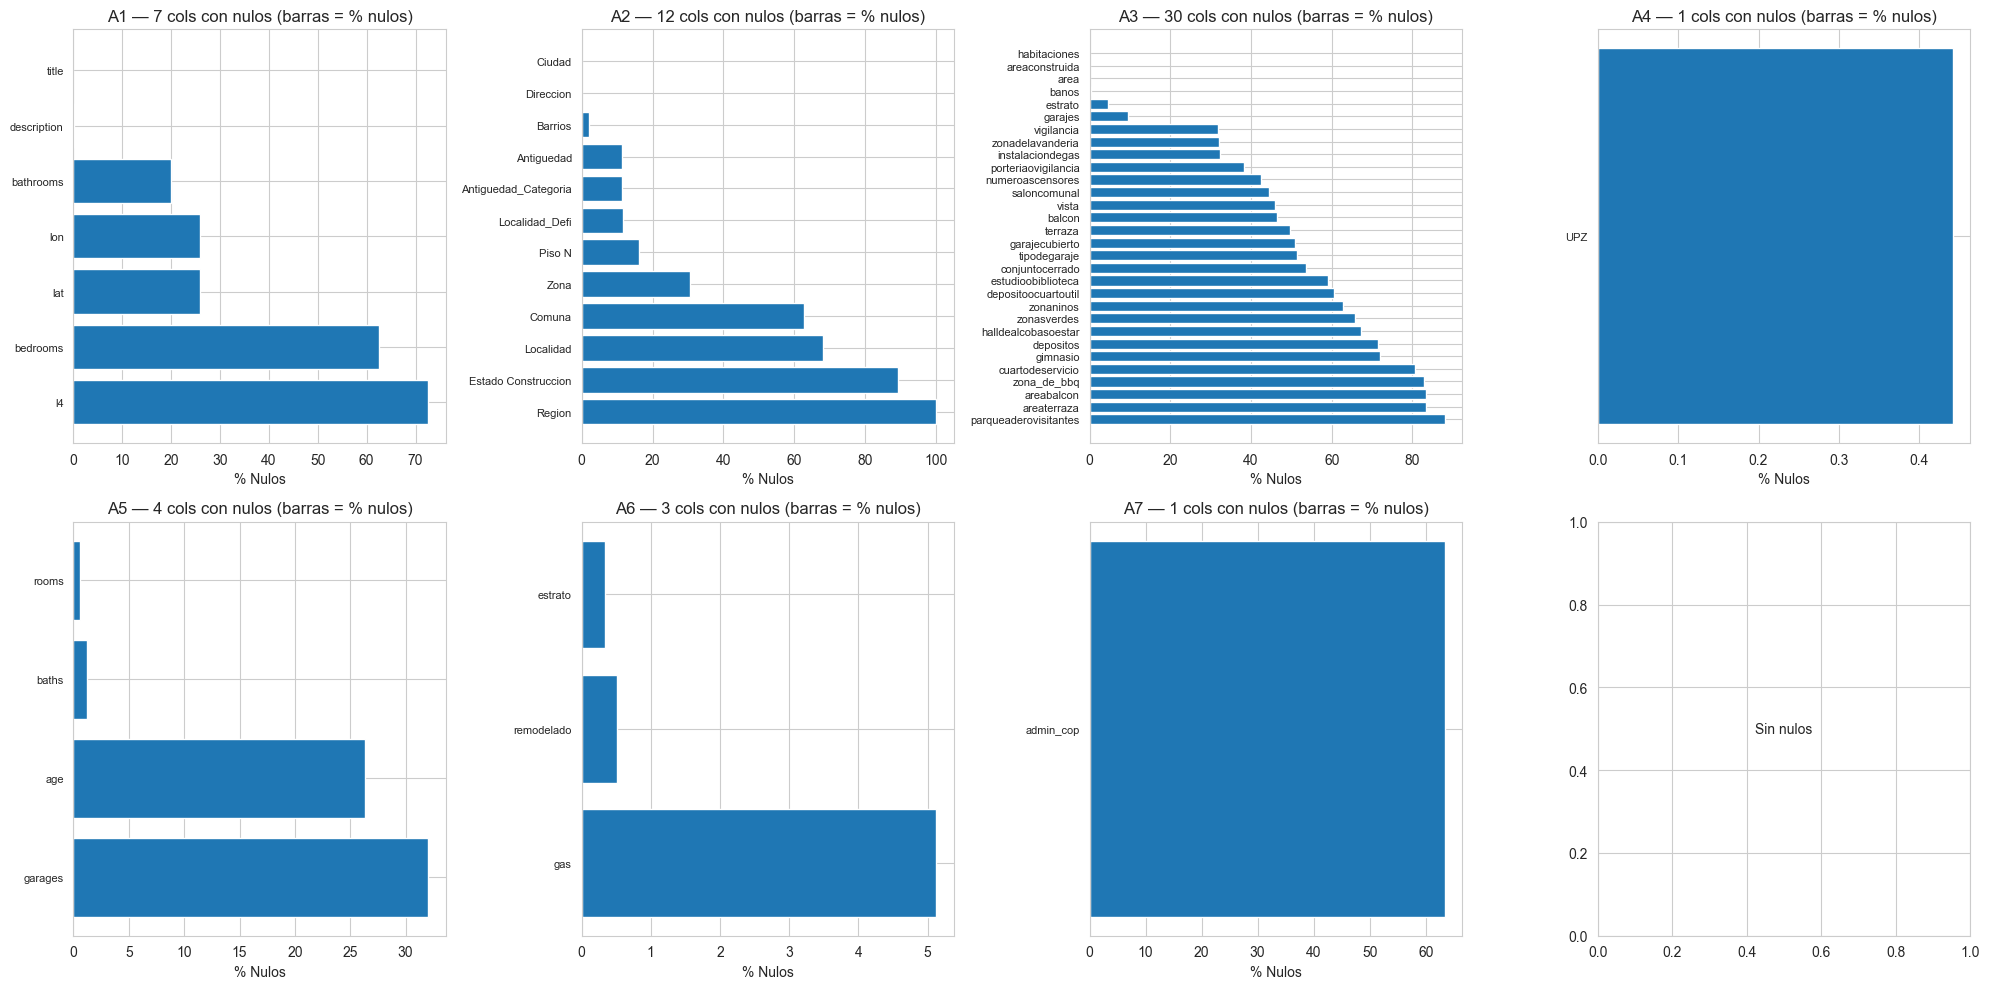

Gráfico guardado en: ..\docs\figures\pct_nulos_por_columna_grupo_a.png


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (fid, _) in enumerate(A_FILES):
    df = datasets[fid]
    if df is None:
        continue

    pct_nulos = df.isnull().mean().sort_values(ascending=False) * 100
    pct_nulos = pct_nulos[pct_nulos > 0]

    if len(pct_nulos) == 0:
        axes[i].text(0.5, 0.5, "Sin nulos", ha="center", va="center")
        continue

    axes[i].barh(range(len(pct_nulos)), pct_nulos.values)
    axes[i].set_yticks(range(len(pct_nulos)))
    axes[i].set_yticklabels(pct_nulos.index, fontsize=8)
    axes[i].set_xlabel("% Nulos")
    axes[i].set_title(f"{fid} — {len(pct_nulos)} cols con nulos (barras = % nulos)")

plt.tight_layout()

path_fig = os.path.join(FIGS, "pct_nulos_por_columna_grupo_a.png")
plt.savefig(path_fig, dpi=150, bbox_inches="tight")

plt.show()

print(f"Gráfico guardado en: {path_fig}")

**Conclusion de nulos por columna:**
- A3 tiene 30+ columnas con algun nivel de nulos; las criticas son areabalcon, areaterraza, zona_de_bbq (>80%).
- A2: Region 100% nulo (columna inutilizable); Estado Construccion 89% nulo.
- A1: l4 73% nulo, bedrooms 62% nulo, lat/lon 26% nulo.
- A7: admin_cop 63% nulo (gasto administrativo no siempre registrado).
- B1: Variacion_%_Apartamentos 73% nulo; IPVU indices 54% nulo.


### Análisis de nulos en área por dataset

In [8]:
print("===== NULOS EN ÁREA POR CIUDAD =====\n")

area_cols_map = {
    "A1": "area",
    "A2": "Area Construida",
    "A3": "area",
    "A4": "Area",
    "A5": "area",
    "A6": "Area",
    "A7": "area_m2",
    "A8": "area",
}

city_cols_map = {
    "A1": "l3",
    "A2": "Ciudad",
    "A3": None,
    "A4": None,
    "A5": "neighbourhood",
    "A6": None,
    "A7": "ciudad",
    "A8": None,
}

for fid, _ in A_FILES:
    df = datasets[fid]
    if df is None:
        continue
    area_col = area_cols_map.get(fid)
    if area_col not in df.columns:
        print(f"{fid}: columna de area no encontrada")
        continue

    pct_nulo_area = df[area_col].isnull().mean() * 100

    city_col = city_cols_map.get(fid)
    if city_col and city_col in df.columns:
        print(f"\n{fid} — {pct_nulo_area:.1f}% area nulo (por ciudad):")
        by_city = df.groupby(city_col)[area_col].apply(lambda x: x.isnull().mean() * 100)
        for city, pct in by_city.sort_values(ascending=False).head(10).items():
            bar = "#" * int(pct / 2)
            print(f"  {str(city):30s} {pct:5.1f}% {bar}")
    else:
        print(f"{fid}: {pct_nulo_area:.1f}% area nulo (sin columna ciudad)")


===== NULOS EN ÁREA POR CIUDAD =====

A1: columna de area no encontrada

A2 — 0.0% area nulo (por ciudad):
  Zipaquirá - Dabeiba              0.0% 
  Abejorral                        0.0% 
  Abrego                           0.0% 
  Acacías                          0.0% 
  Acacías - Jamundí                0.0% 
  Acacías - Palmira                0.0% 
  Agua de dios                     0.0% 
  Aguadas                          0.0% 
  Alcala                           0.0% 
  Alcala - Bogotá                  0.0% 
A3: 0.0% area nulo (sin columna ciudad)
A4: columna de area no encontrada

A5 — 0.0% area nulo (por ciudad):
  zuñiga envigado                  0.0% 
  12 De Octubre                    0.0% 
  19 de abril                      0.0% 
  ALTO DE LAS PALMAS               0.0% 
  ALTO DE MISAEL                   0.0% 
  AMAGA                            0.0% 
  AMERICA                          0.0% 
  AMERICA NIZA                     0.0% 
  sabaneta san jose                0.0% 
  sal

**Conclusion de nulos en area:**
- A2, A3, A5, A7, A8 tienen 0% de nulos en area — dato confiable.
- A1, A4, A6 no tienen columna de area directa; requeriran mapeo desde otras fuentes en Fase 3.
- Cuando existe columna de ciudad, los nulos en area no se concentran en ninguna ciudad especifica.


### Análisis de nulos en precio por dataset

In [9]:
print("===== NULOS EN PRECIO POR CIUDAD =====\n")

price_cols_map = {
    "A1": "price",
    "A2": "Precio",
    "A3": "valor",
    "A4": "Valor",
    "A5": "price",
    "A6": "precio",
    "A7": "precio_cop",
    "A8": "precios",
}

for fid, _ in A_FILES:
    df = datasets[fid]
    if df is None:
        continue
    price_col = price_cols_map.get(fid)
    if price_col not in df.columns:
        print(f"{fid}: columna precio no encontrada")
        continue

    pct = df[price_col].isnull().mean() * 100
    city_col = city_cols_map.get(fid)
    if city_col and city_col in df.columns:
        print(f"{fid}: {pct:.1f}% precio nulo (por ciudad):")
        by_city = df.groupby(city_col)[price_col].apply(lambda x: x.isnull().mean() * 100)
        for city, v in by_city.sort_values(ascending=False).head(5).items():
            print(f"    {str(city):30s} {v:5.1f}%")
    else:
        print(f"{fid}: {pct:.1f}% precio nulo")


===== NULOS EN PRECIO POR CIUDAD =====

A1: 0.0% precio nulo (por ciudad):
    Útica                            0.0%
    Abejorral                        0.0%
    Acacías                          0.0%
    Acandí                           0.0%
    Agua de Dios                     0.0%
A2: 0.0% precio nulo (por ciudad):
    Zipaquirá - Dabeiba              0.0%
    Abejorral                        0.0%
    Abrego                           0.0%
    Acacías                          0.0%
    Acacías - Jamundí                0.0%
A3: 0.0% precio nulo
A4: 0.0% precio nulo
A5: 0.0% precio nulo (por ciudad):
    zuñiga envigado                  0.0%
    12 De Octubre                    0.0%
    19 de abril                      0.0%
    ALTO DE LAS PALMAS               0.0%
    ALTO DE MISAEL                   0.0%
A6: 0.0% precio nulo
A7: 0.0% precio nulo (por ciudad):
    Cali                             0.0%
    Guaduas                          0.0%
    Otros municipios                 0.0%
 

**Conclusion de nulos en precio:**
- Todos los datasets tienen 0% de nulos en precio — dato fundamental completamente disponible.
- Esto es esperable: el precio es el campo principal en cualquier plataforma inmobiliaria.
- No se requieren acciones correctivas para precio en Fase 3.


### Guardar reporte de nulos completo

In [10]:
print("===== REPORTE DE NULOS COMPLETO =====\n")

nulos_report = []
for fid, _ in ALL_FILES:
    df = datasets[fid]
    if df is None:
        continue
    for col in df.columns:
        n_nulos = df[col].isnull().sum()
        if n_nulos > 0:
            nulos_report.append({
                "Dataset": fid,
                "Columna": col,
                "Nulos": n_nulos,
                "Total filas": len(df),
                "% Nulos": round(n_nulos / len(df) * 100, 2),
                "Dtype": str(df[col].dtype),
            })

df_nulos = pd.DataFrame(nulos_report)
df_nulos = df_nulos.sort_values("% Nulos", ascending=False)
display(df_nulos.head(30))
print(f"\nTotal columnas con nulos: {len(df_nulos)}")

df_nulos.to_csv(os.path.join(PROC, "reporte_nulos_completo.csv"), index=False)
print(f"Reporte guardado: {PROC}/reporte_nulos_completo.csv")


===== REPORTE DE NULOS COMPLETO =====



,Dataset,Columna,Nulos,Total filas,% Nulos,Dtype
12,A2,Region,142833,142833,100.00,float64
16,A2,Estado Construccion,127409,142833,89.20,object
38,A3,parqueaderovisitantes,127987,145552,87.93,float64
22,A3,areaterraza,121195,145552,83.27,float64
20,A3,areabalcon,121195,145552,83.27,float64
45,A3,zona_de_bbq,120685,145552,82.92,float64
26,A3,cuartodeservicio,117209,145552,80.53,float64
70,B1,Variacion_%_Apartamentos,243,332,73.19,float64
2,A1,l4,724692,997623,72.64,object
33,A3,gimnasio,104808,145552,72.01,float64



Total columnas con nulos: 75
Reporte guardado: ..\data\processed/reporte_nulos_completo.csv


**Conclusion del reporte completo de nulos:**
- 75 columnas con al menos un valor nulo en total (A+B).
- A3 concentra la mayoria de las columnas con >50% nulos (amenities: gimnasio, saloncomunal, bbq, etc.).
- B1 tiene nulos sistematicos en indices por ciudad (19% en IPVNB real/nominal, 54% en IPVU, 73% en Variacion).
- Se recomienda revisar si columnas con >70% nulos deben excluirse del analisis.


### Patrones de nulos por dataset — tabla pivot

In [11]:
nulos_pivot = df_nulos.pivot_table(
    index="Dataset",
    columns="Columna",
    values="% Nulos",
    aggfunc="first"
)
print("===== MATRIZ DE NULOS (% por Dataset/Columna) =====\n")
display(nulos_pivot.fillna(0).style.background_gradient(cmap="Reds", axis=None))


===== MATRIZ DE NULOS (% por Dataset/Columna) =====



Columna,Antiguedad,Antiguedad_Categoria,Auxilio_transporte,Barrios,Ciudad,Comuna,Direccion,Estado Construccion,Incremento_$,Incremento_%,Localidad,Localidad_Defi,Piso N,Region,UPZ,Variacion_%_Apartamentos,Zona,admin_cop,age,area,areabalcon,areaconstruida,areaterraza,balcon,banos,bathrooms,baths,bedrooms,conjuntocerrado,cuartodeservicio,depositoocuartoutil,depositos,description,estrato,estudioobiblioteca,garages,garajecubierto,garajes,gas,gimnasio,habitaciones,halldealcobasoestar,instalaciondegas,ipvnbr_índice_nominal_agregado,ipvnbr_índice_nominal_alrededores_de_bogotá,ipvnbr_índice_nominal_bogotá,ipvnbr_índice_nominal_cali,ipvnbr_índice_nominal_medellín,ipvnbr_índice_real_agregado,ipvnbr_índice_real_alrededores_de_bogotá,ipvnbr_índice_real_bogotá,ipvnbr_índice_real_cali,ipvnbr_índice_real_medellín,ipvu_indice_nominal,ipvu_indice_real,l4,lat,lon,numeroascensores,parqueaderovisitantes,pet,porteriaovigilancia,remodelado,rooms,saloncomunal,terraza,tipodegaraje,title,vigilancia,vista,zona_de_bbq,zonadelavanderia,zonaninos,zonasverdes
Dataset,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.970000,0.000000,62.430000,0.000000,0.000000,0.000000,0.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.640000,25.990000,25.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2,11.350000,11.350000,0.000000,2.230000,0.010000,62.800000,0.140000,89.200000,0.000000,0.000000,67.930000,11.800000,16.100000,100.000000,0.000000,0.000000,30.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,83.270000,0.020000,83.270000,46.310000,0.370000,0.000000,0.000000,0.000000,53.610000,80.530000,60.530000,71.460000,0.000000,4.580000,59.070000,0.000000,50.910000,9.530000,0.000000,72.010000,0.010000,67.160000,32.290000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.540000,87.930000,0.000000,38.310000,0.000000,0.000000,44.440000,49.660000,51.500000,0.000000,31.920000,45.880000,82.920000,32.090000,62.850000,65.710000
A4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0

**Conclusion de la matriz de nulos:**
- A3 es el dataset mas problematico: 25+ columnas con >30% nulos.
- A1 tiene 4 columnas con nulos significativos (>20%).
- A2 tiene 6 columnas con >10% nulos, incluyendo Region (100%) y Estado Construccion (89%).
- B1 tiene 12 columnas con ~19% nulos (indices por ciudad).
- Los datasets pequenos (A4, A6, A7, A8, B2-B8) tienen nulos minimos o inexistentes.


---
## Resumen: Calidad de Datos - Diagnóstico Inicial

- Se cargaron y validaron los 16 datasets del proyecto.
- Se calcularon métricas de calidad de datos, incluyendo registros, columnas, duplicados y valores nulos.
- Se cuantificó el porcentaje de nulos en variables críticas como precio y área.
- Se analizaron patrones de valores faltantes por dataset y por ciudad.
- Se generaron visualizaciones para identificar distribución y concentración de nulos.
- Se documentaron hallazgos y recomendaciones para la fase de limpieza y estandarización de datos.

**Outputs generados:**
- `data/processed/calidad_grupo_a.csv`
- `data/processed/calidad_grupo_b.csv`
- `data/processed/reporte_nulos_completo.csv`
- `docs/figures/mapa_calor_nulos_grupo_a.png`
- `docs/figures/pct_nulos_por_columna_grupo_a.png`

**Hallazgos clave:**
- Los datasets A3 (House Prediction) y A8 (UPZ) presentan una alta completitud de datos y baja proporción de valores faltantes.
- A1 (Properati) concentra nulos principalmente en variables de área y ubicación geográfica.
- A2 (FincaRaiz) contiene varias columnas con porcentajes elevados de valores faltantes que requerirán tratamiento específico.
- La variable precio presenta niveles bajos de ausencia en la mayoría de los datasets, generalmente inferiores al 5%.
- Los patrones de nulos identificados permiten definir estrategias diferenciadas de imputación, eliminación o conservación según la relevancia de cada variable.